In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load data, here csvs with the KRAS TRN and drug scores for each cluster (RFI)
df = pd.read_csv('data/KRAS_scores_cleaned.csv')
df_drug = pd.read_csv('data/KRAS_logodds_drug_sorted.csv')

In [3]:
# Get score columns
score_cols = [c for c in df.columns if c.startswith("score_")]

# Max score per pathway
df["max_score"] = df[score_cols].max(axis=1)

# Sort
df_sorted = df.sort_values("max_score",ascending=False).reset_index(drop=True)

# Find TEAD2
tead2_idx = df_sorted.index[df_sorted["pathway"] == "TEAD2"][0]
tead2_val = df_sorted.loc[tead2_idx, "max_score"]

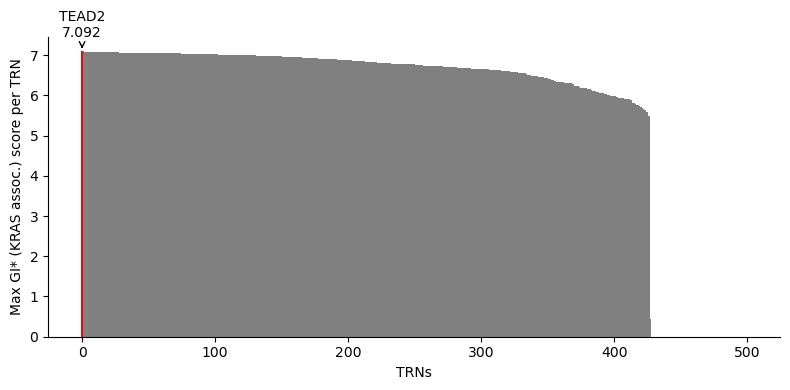

In [4]:
# Create colors
colors = ["gray"] * len(df_sorted)
colors[tead2_idx] = "red"

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    range(len(df_sorted)),
    df_sorted["max_score"],
    color=colors,
    width=1.0,
    linewidth=0
)

# Annotate TEAD2
ax.annotate(
    f"TEAD2\n{tead2_val:.3f}",
    xy=(tead2_idx, tead2_val),
    xytext=(tead2_idx, tead2_val + (df_sorted["score_3"].max() * 0.05)),
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

# Set axes labels
ax.set_xlabel("TRNs")
ax.set_ylabel("Max GI* (KRAS assoc.) score per TRN")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Show plot
plt.tight_layout()
plt.show()

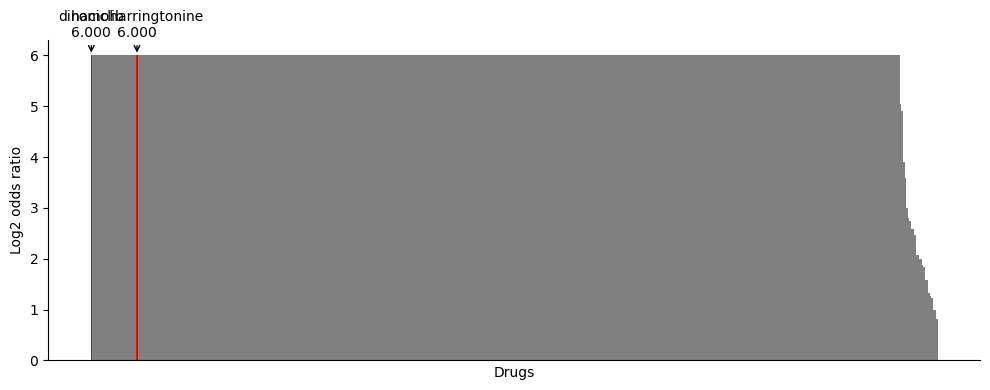

In [5]:
# Drugs to highlight
highlight_drugs = ["dinaciclib", "homoharringtonine"]

# Create colors
colors = [
    "red" if drug in highlight_drugs else "gray"
    for drug in df_drug["drug"]
]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    range(len(df_drug)),
    df_drug["logodds"],
    color=colors,
    width=1.0,
    linewidth=0
)

# Annotate highlighted drugs
y_offset = df_drug["logodds"].max() * 0.05

for drug in highlight_drugs:
    match = df_drug.index[df_drug["drug"] == drug]

    if len(match) == 0:
        print(f"{drug} not found in df")
        continue

    idx = match[0]
    val = df_drug.loc[idx, "logodds"]

    ax.annotate(
        f"{drug}\n{val:.3f}",
        xy=(idx, val),
        xytext=(idx, val + y_offset),
        ha="center",
        va="bottom",
        arrowprops=dict(arrowstyle="->")
    )

# Set axes labels
ax.set_xlabel("Drugs")
ax.set_ylabel("Log2 odds ratio")

# Format to make less crowded
ax.set_xticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Show plot
plt.tight_layout()
plt.show()